<a href="https://colab.research.google.com/github/SUVIDHIJAIN23/Time-Series-Analysis---Airpassengers/blob/main/forecasting_methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Forecasting AirPassengers: A Methodological Comparison

A systematic evaluation of baseline, statistical (ETS, SARIMA), and
gradient-boosted (LightGBM) forecasting methods on the Box-Jenkins
airline passengers dataset (1949-1960, monthly, 144 observations).

**Goal:** Document the tradeoffs between model families through residual
diagnostics, rolling-origin cross-validation, and target transformation
experiments.

**Headline CV MAPE:** LightGBM (log + differences) achieves 0.060 vs.
AutoARIMA's 0.075 and ETS ceiling of ~0.10.

In [1]:
# Colab-only cell. Skip if running locally with requirements.txt installed.
!pip install -q statsforecast mlforecast utilsforecast lightgbm statsmodels seaborn

## Imports

We use three library families:

1. **Standard data science** — pandas, numpy, matplotlib, seaborn
2. **statsmodels** — for STL decomposition, ACF/PACF plots, stationarity tests
3. **Nixtla ecosystem** — statsforecast (classical models), mlforecast (ML
   models), utilsforecast (evaluation, plotting). All Nixtla libraries share
   the same long-format convention: `unique_id`, `ds`, `y`.

In [2]:
# Standard data science
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Statsmodels: decomposition, diagnostics, stationarity
from statsmodels.tsa.seasonal import STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

# Nixtla: statistical forecasting
from statsforecast import StatsForecast
from statsforecast.models import (
    Naive, SeasonalNaive, HistoricAverage, RandomWalkWithDrift,
    AutoETS, ARIMA, AutoARIMA,
)
from statsforecast.utils import AirPassengersDF

# Nixtla: ML forecasting
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from mlforecast.lag_transforms import RollingMean, ExpandingMean
from mlforecast.utils import PredictionIntervals
import lightgbm as lgb

# Nixtla: evaluation and plotting
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, mape, smape, mse

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plotting aesthetics
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## Dataset: AirPassengers

The Box-Jenkins airline passengers dataset — monthly counts of international
airline passengers from January 1949 to December 1960, sourced from Box &
Jenkins (1976). We use the version distributed with Nixtla's statsforecast
(`AirPassengersDF`), already in the required `unique_id / ds / y` long format.

In [3]:
df = AirPassengersDF.copy()

# Sanity check: structure, range, coefficient of variation
print(f"Shape: {df.shape}")
print(f"Date range: {df['ds'].min().date()} to {df['ds'].max().date()}")
print(f"y range: {df['y'].min():.0f} to {df['y'].max():.0f}")
print(f"Coefficient of variation: {df['y'].std() / df['y'].mean():.2f}")
print(f"\nFirst 3 rows:")
print(df.head(3))

Shape: (144, 3)
Date range: 1949-01-31 to 1960-12-31
y range: 104 to 622
Coefficient of variation: 0.43

First 3 rows:
   unique_id         ds      y
0        1.0 1949-01-31  112.0
1        1.0 1949-02-28  118.0
2        1.0 1949-03-31  132.0


**Observations on structure:**

- 144 monthly observations across 12 full annual cycles
- Coefficient of variation ≈ 0.43 (high for a single series), indicating
  substantial trend or seasonality
- Max/min ratio ≈ 6×, characteristic of a strongly growing series
- Single series — `unique_id` is constant at 1.0. Nixtla's multi-series
  conventions still apply, which will matter for the ML section where
  mlforecast's global-model framework uses `unique_id` to distinguish
  series even when there's only one.

12 cycles is enough for classical seasonal models (SARIMA, ETS) which need
≥5 full cycles, but insufficient for deep learning approaches that typically
require thousands of observations.

## Section 1: Exploratory Data Analysis

Before fitting any model, we form domain-driven hypotheses about the
data-generating process and verify them visually. This "hypothesize first,
plot second" habit is the single biggest differentiator between running
models on autopilot and doing forecasting thoughtfully.

### Hypotheses to verify

1. **Trend:** Post-WWII commercial aviation expanded rapidly as disposable
   income rose and the jet age began (~1958). We expect a strong upward
   trend, potentially accelerating in later years.

2. **Seasonality:** Leisure travel in the Northern Hemisphere peaks in
   summer (July–August vacation travel), with a secondary December peak
   (Christmas travel). Troughs should occur in February and November.

3. **Seasonal amplitude behavior:** As the market grows, we expect the
   *absolute* size of seasonal swings to grow with the level — i.e.,
   **multiplicative seasonality**, not additive. If true, a log-transform
   should convert the series to additive form.

The next three cells test each hypothesis.

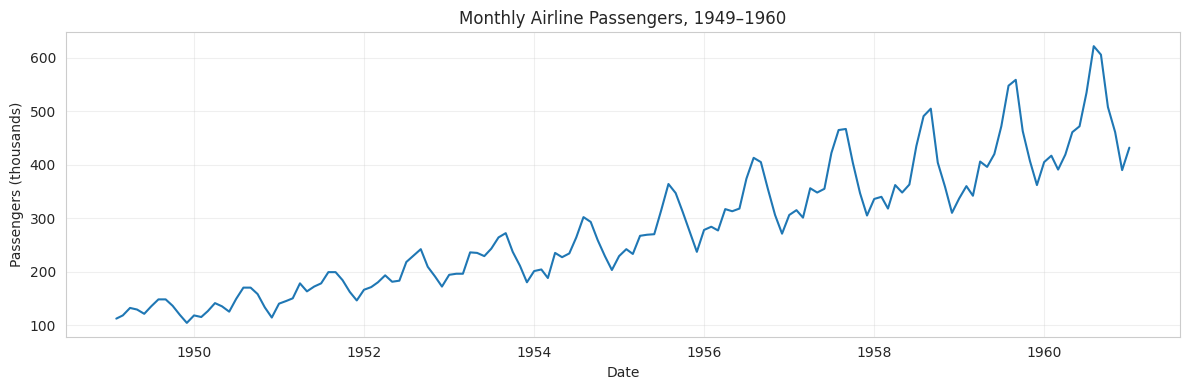

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df['ds'], df['y'])
ax.set_title('Monthly Airline Passengers, 1949–1960')
ax.set_xlabel('Date')
ax.set_ylabel('Passengers (thousands)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Hypothesis 1 confirmed.** The series shows a strong upward trend. Whether
it is linear or exponential is not yet clear — we test this next.

**Hypothesis 2 partially visible.** Annual cycles are obvious. A dual-peak
structure is present but needs a closer look (next section).

**Hypothesis 3 strongly supported.** The amplitude of oscillations grows
substantially over time. In 1949 the peak-to-trough swing is ~45; by 1960
it is ~230 — a 5× increase, while the series level grew only 4×. This is
the fingerprint of multiplicative seasonality.

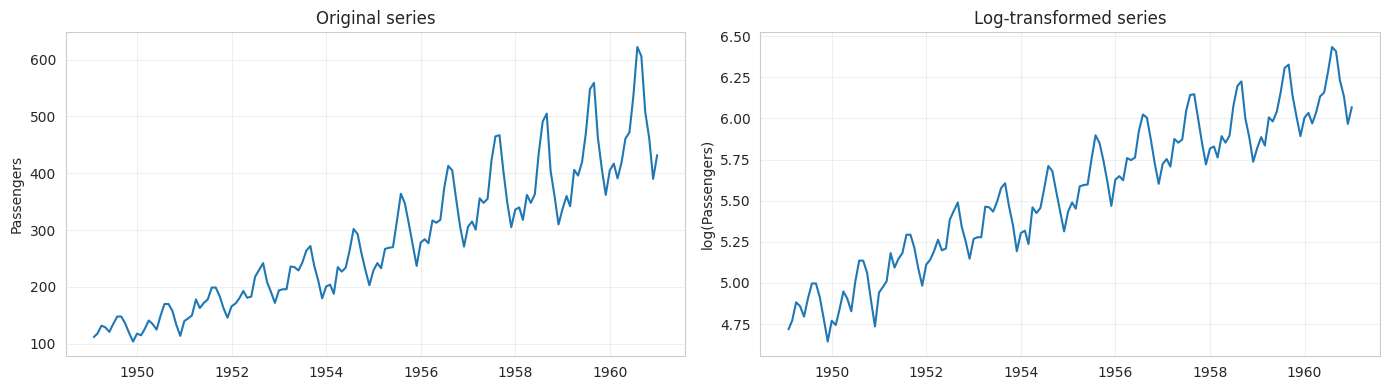

In [5]:
# Compare linear vs. exponential trend via log-transform
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df['ds'], df['y'])
axes[0].set_title('Original series')
axes[0].set_ylabel('Passengers')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['ds'], np.log(df['y']))
axes[1].set_title('Log-transformed series')
axes[1].set_ylabel('log(Passengers)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Diagnosis: the trend is exponential, not linear.**

The log-transformed series has a near-linear trend, which means the original
series grows exponentially. This is a foundational finding that shapes
every modeling decision from here:

- **For ETS:** we can fit multiplicative components on raw-y *or* additive
  components on log-y. Both paths are coherent; mixing them is not.
- **For ARIMA:** log-transform is effectively mandatory, because ARIMA is
  a purely additive framework that cannot natively model multiplicative
  seasonality.
- **For ML (LightGBM):** log-transform stabilizes the error scale and,
  when combined with differencing, lets the model learn patterns in
  growth rates (scale-invariant) rather than absolute values.

> **Principle:** When seasonal amplitude grows with the level, seasonality
> is multiplicative. This often co-occurs with exponential trend, and a
> log-transform converts both to additive form.

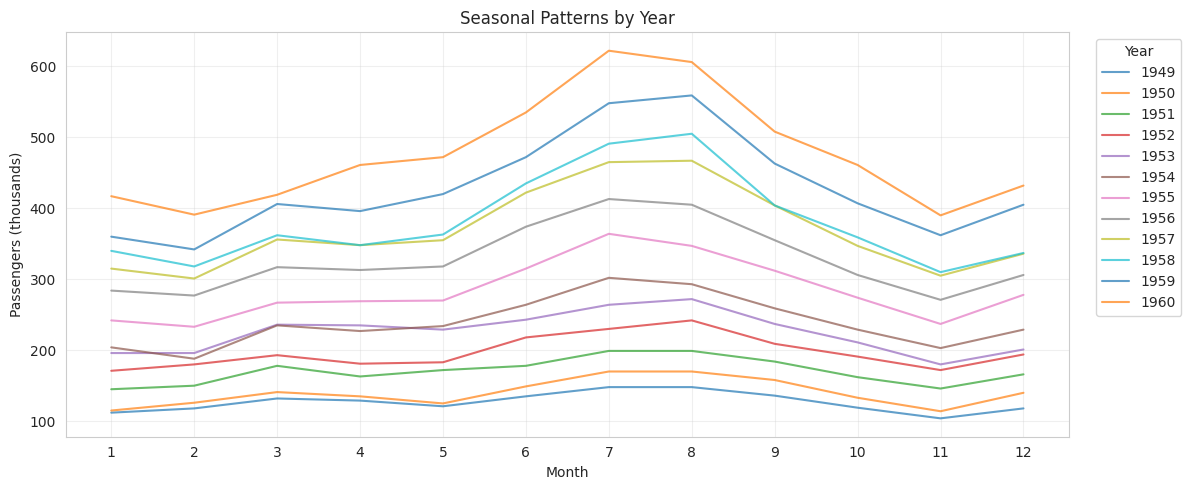

In [6]:
# Enrich the dataframe with year/month metadata for grouping
df_agg = df.assign(
    year=df['ds'].dt.year,
    month=df['ds'].dt.month,
    month_name=df['ds'].dt.month_name(),
)

# Monthly patterns over years: one line per year, x-axis is month
fig, ax = plt.subplots(figsize=(12, 5))
for year, group in df_agg.groupby('year'):
    ax.plot(group['month'], group['y'], label=str(year), alpha=0.7)
ax.set_title('Seasonal Patterns by Year')
ax.set_xlabel('Month')
ax.set_ylabel('Passengers (thousands)')
ax.set_xticks(range(1, 13))
ax.legend(title='Year', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Hypothesis 2 confirmed with nuance.** Every year shows:

- A **dominant summer peak** in July–August
- A **secondary December peak** (smaller but visible)
- **Troughs in February and November**

The dual-peak structure is real, but summer dominates in this era. (Modern
airline data post-2000 typically shows a much stronger December peak due to
Christmas-travel culture growth, a domain detail that would inform
interpretation of contemporary datasets.)

**Seasonal amplitude grows with the level:** the 1960 peak is ~3× the 1949
peak, while the 1960 trough is also ~3× the 1949 trough — the *ratio* stays
roughly constant, confirming multiplicative structure.

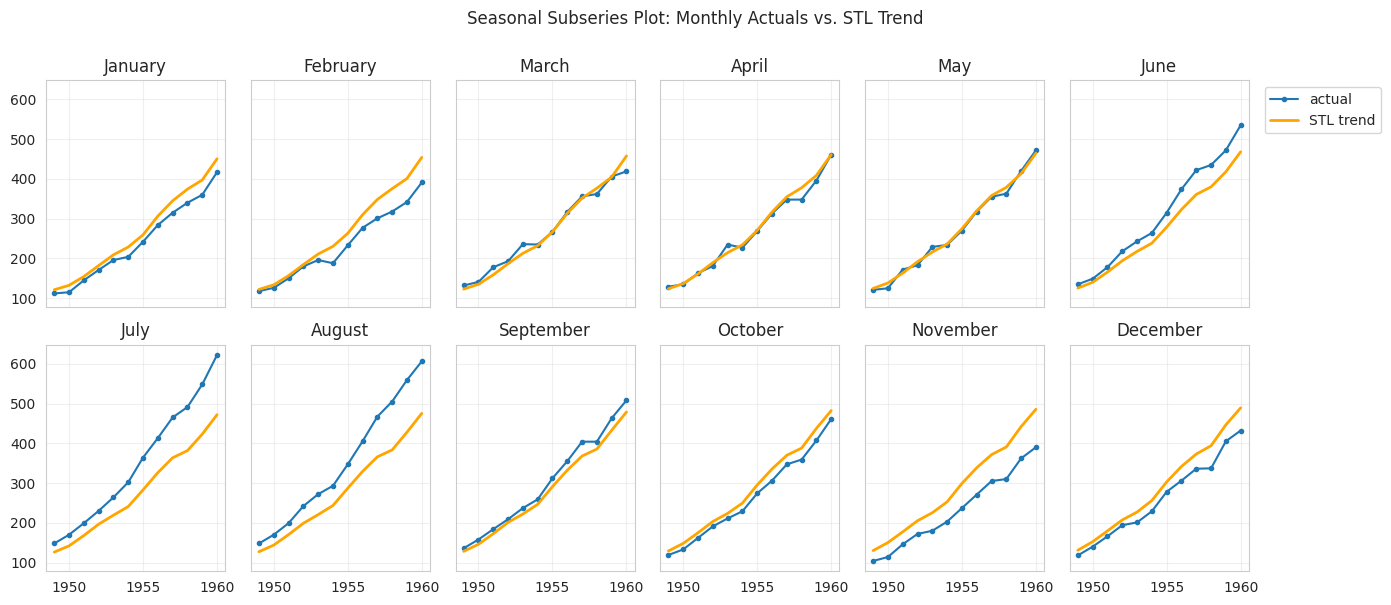

In [7]:
# STL decomposition on log-y to extract the trend component
stl = STL(df.set_index('ds')['y'].apply(np.log), period=12, robust=True).fit()

# Attach STL components back to df_agg on raw scale (exponentiate back)
df_agg['trend'] = np.exp(stl.trend.values)
df_agg['seasonal_component'] = np.exp(stl.seasonal.values)
df_agg['residual'] = np.exp(stl.resid.values)

# 12-panel seasonal subseries plot with STL trend overlay
fig, axes = plt.subplots(2, 6, figsize=(14, 6), sharey=True, sharex=True)
for (month, group), ax in zip(df_agg.groupby('month'), axes.flatten()):
    ax.plot(group['year'], group['y'], label='actual', marker='o', markersize=3)
    ax.plot(group['year'], group['trend'], label='STL trend', color='orange', linewidth=2)
    ax.set_title(group['month_name'].iloc[0])
    ax.grid(True, alpha=0.3)

fig.suptitle('Seasonal Subseries Plot: Monthly Actuals vs. STL Trend', y=1.00)
axes[0, 5].legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

**Reading the subseries plot (one panel per month, year on x-axis):**

- **Every panel shows an upward trend** — growth applies to all months, not
  just peak months.
- **Panels diverge from the STL trend in characteristic ways:**
  - *July and August:* actuals sit progressively *above* trend, and the
    gap widens from 1949 to 1960. Peak months are intensifying
    over the decade.
  - *November:* actuals sit *below* trend consistently — a negative
    seasonal effect.
  - *January–March:* actuals track the trend closely — near-neutral
    seasonal effect.

The widening gap between July/August actuals and the trend is **the
multiplicative seasonality signature made visible without formal
decomposition.** If seasonality were additive, every panel's actuals would
sit parallel to the trend with a constant offset. They don't — peak months
accelerate away from the trend, trough months do not.

This visualization tells the entire multiplicative-seasonality story in one
picture, and it would be a useful artifact to include in a stakeholder
presentation explaining why simple year-over-year comparisons mislead on
this kind of data.

## Section 2: STL Decomposition and Residual Diagnostics

STL (Seasonal-Trend decomposition using LOESS) splits a series into trend,
seasonal, and residual components. For a multiplicative series, we
decompose on the log scale so that the additive STL framework applies
cleanly: `log(y) = T + S + R`.

After decomposition, we run the full diagnostic triptych — residuals over
time, histogram, and autocorrelation function — plus a formal Ljung-Box
test for independence. This is the diagnostic workflow we will repeat for
every model fit later in the notebook.

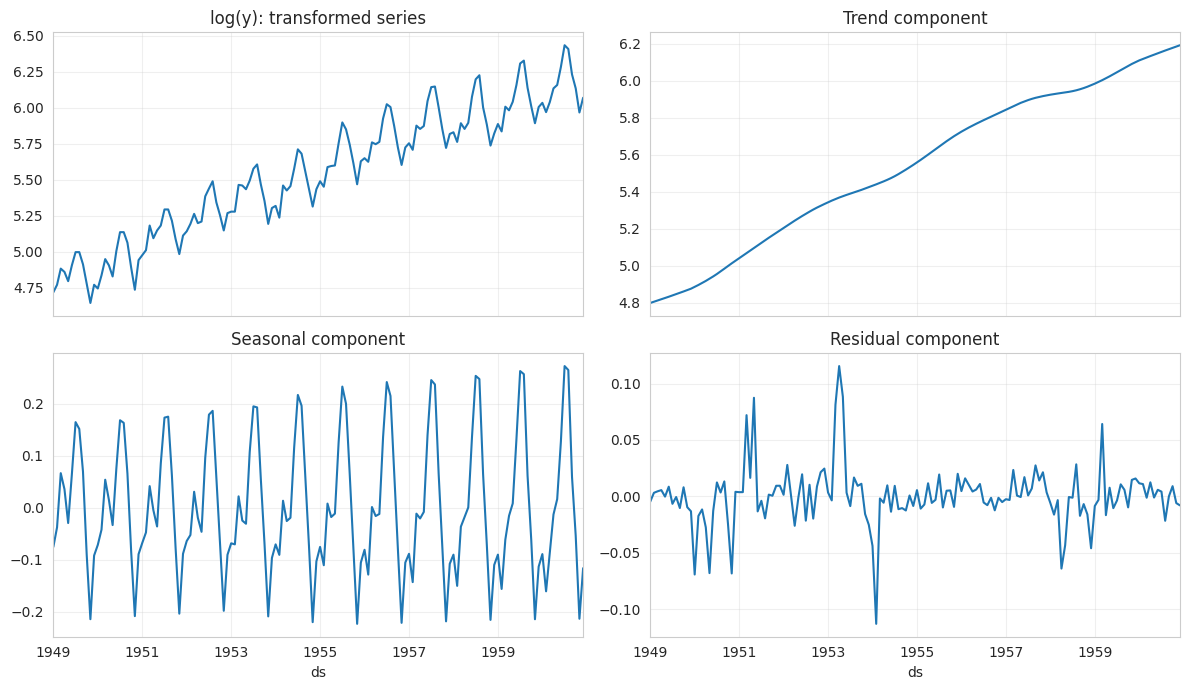

In [8]:

# Decompose log-y into trend, seasonal, residual
log_y = np.log(df.set_index('ds')['y'])
stl_result = STL(log_y, period=12, robust=True).fit()

# Visualize the decomposition
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
log_y.plot(ax=axes[0, 0], title='log(y): transformed series')
stl_result.trend.plot(ax=axes[0, 1], title='Trend component')
stl_result.seasonal.plot(ax=axes[1, 0], title='Seasonal component')
stl_result.resid.plot(ax=axes[1, 1], title='Residual component')
for ax in axes.flatten():
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Reading the decomposition:**

- **Trend:** smooth, monotonically increasing, with subtle slope changes
  reflecting periods of faster vs. slower aviation growth (post-Korean War
  recovery in the early '50s; the jet age acceleration in the late '50s).
- **Seasonal:** stable repeating pattern with the dual-peak structure.
  Range approximately −0.22 to +0.27 in log space.
- **Residual:** appears random on visual inspection. Whether it is
  statistically white noise is the question the diagnostics answer next.

**Quantifying the seasonal effect in business language:**

Log-space bounds of `[−0.22, +0.27]` translate to raw-scale multipliers:

- Trough months: `exp(−0.22) ≈ 0.80` → **~20% below trend**
- Peak months: `exp(+0.27) ≈ 1.31` → **~31% above trend**

A stakeholder-ready framing: *"After accounting for underlying growth,
passenger volumes in the weakest months run about 20% below trend, while
peak months run about 31% above — a 50-percentage-point seasonal swing that
any capacity planning must account for explicitly."*

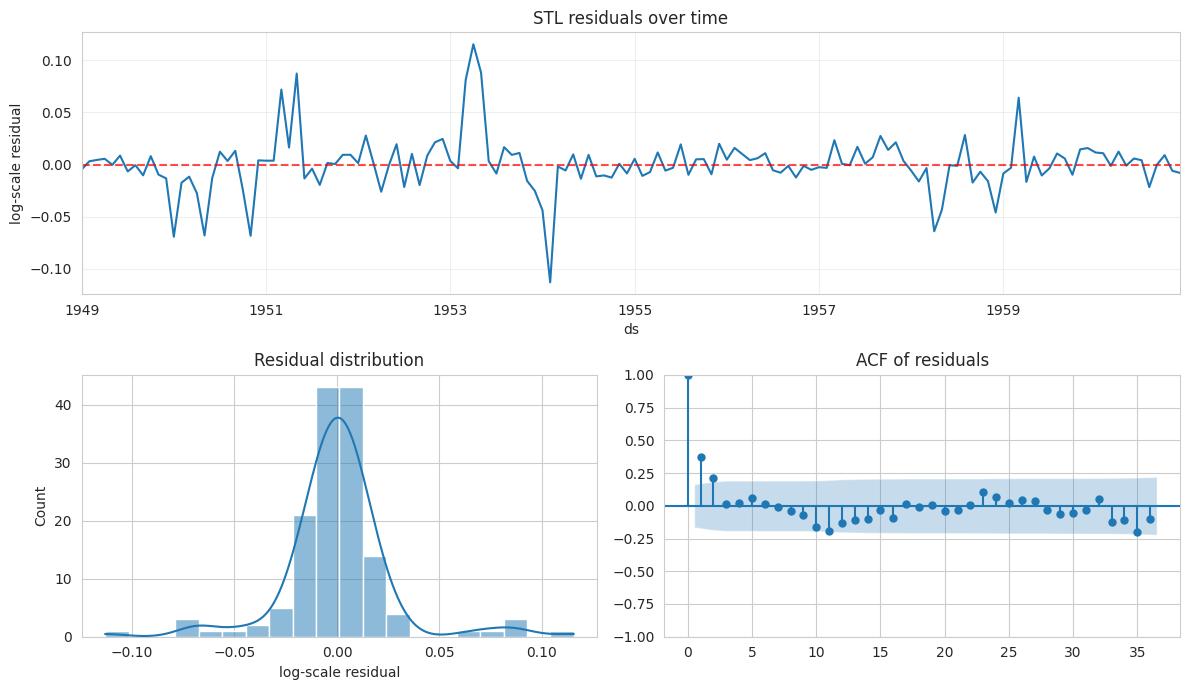

In [9]:
residuals = stl_result.resid.dropna()

# Three-panel diagnostic: residuals over time, histogram, ACF
fig, axes = plt.subplot_mosaic(
    [['resid_time', 'resid_time'],
     ['resid_hist', 'resid_acf']],
    figsize=(12, 7),
)

# Panel 1: residuals over time
residuals.plot(ax=axes['resid_time'])
axes['resid_time'].axhline(0, color='red', linestyle='--', alpha=0.7)
axes['resid_time'].set_title('STL residuals over time')
axes['resid_time'].set_ylabel('log-scale residual')
axes['resid_time'].grid(True, alpha=0.3)

# Panel 2: histogram with KDE
sns.histplot(residuals, bins=20, kde=True, ax=axes['resid_hist'])
axes['resid_hist'].set_title('Residual distribution')
axes['resid_hist'].set_xlabel('log-scale residual')

# Panel 3: ACF
plot_acf(residuals, lags=36, ax=axes['resid_acf'])
axes['resid_acf'].set_title('ACF of residuals')

plt.tight_layout()
plt.show()

**Visual diagnostics:**

- **Time plot:** mostly centered on zero with both positive and negative
  values, but a notable negative spike around 1954 (roughly −0.12 in log
  space, or an ~11% deviation on raw scale). Not cleanly white noise.
- **Histogram:** approximately normal, with a mild left tail from the
  1954 outlier. Acceptable for most purposes.
- **ACF:** **lag-1 autocorrelation ≈ 0.3, clearly outside the confidence
  band.** There is short-range structure STL did not capture.

Visual inspection suggests the residuals are *not* independent. We confirm
with a formal test.

In [10]:
# Ljung-Box: formal test for residual independence at multiple lag horizons
lb_result = acorr_ljungbox(residuals, lags=[6, 12, 24], return_df=True)

print("Ljung-Box test on STL residuals:")
print("H0: residuals are independent at the tested lag\n")
for lag in [6, 12, 24]:
    p = lb_result.loc[lag, 'lb_pvalue']
    verdict = 'REJECT H0 → autocorrelation present' if p < 0.05 else 'fail to reject'
    print(f"  Lag {lag:2d}: p = {p:.4f}  ({verdict})")

Ljung-Box test on STL residuals:
H0: residuals are independent at the tested lag

  Lag  6: p = 0.0001  (REJECT H0 → autocorrelation present)
  Lag 12: p = 0.0000  (REJECT H0 → autocorrelation present)
  Lag 24: p = 0.0014  (REJECT H0 → autocorrelation present)


**Formal diagnosis confirmed.** All three p-values are essentially zero.
Residuals are decisively not white noise at short (lag 6), seasonal
(lag 12), and longer (lag 24) horizons.

**Interpretation:**

- **Short-lag autocorrelation** (visible as the lag-1 spike in the ACF) is
  "local momentum" — if this month's residual was positive, next month's
  residual tends to be too. This is the signature of unmodeled AR structure.
- **Seasonal-lag autocorrelation** at 12 and 24 indicates STL did not fully
  capture the seasonal pattern, likely because the seasonality is evolving
  over time (we saw July/August amplitude growing faster than other months
  in the subseries plot).

> **Important principle:** Decomposition is not a forecasting model.
> STL separates trend and seasonality but leaves short-term dynamics and
> evolving-seasonality structure in the residual. A proper forecasting
> model (ARIMA with AR terms, ETS with updating seasonal components, or
> an ML model with appropriate features) should be able to exploit this
> remaining signal.

This finding — exploitable structure remains after STL — motivates the
forecasting-model comparisons in the rest of the notebook.

### A habit worth forming

Every model we fit from here will be evaluated with this same
triptych-plus-Ljung-Box workflow. The pattern to internalize:

| Pattern | Likely next step |
|---|---|
| ACF dies quickly, histogram symmetric, Ljung-Box passes | Model is extracting all structure |
| Lag-1 ACF spike | Add AR(1) term (ARIMA) or non-linear features (ML) |
| Lag-12 ACF spike | Seasonal differencing or seasonal AR/MA term |
| Asymmetric histogram, heteroscedastic residuals | Check transform (log?), check for outliers |

## Section 3: Train/Test Split and Baseline Forecasts

Every modeling decision from this point forward is made on the **training
set only**. The test set is sealed until final evaluation.

We hold out 1956-01 through 1960-12 (60 months, 5 years) and fit on the
remainder (84 months). This is a l

In [11]:
# Train/test split — cutoff at end of 1955
cutoff = pd.Timestamp('1955-12-31')
train = df[df['ds'] <= cutoff].copy()
test = df[df['ds'] > cutoff].copy()

H = len(test)  # forecast horizon = number of test observations

print(f"Train: {len(train)} obs, {train['ds'].min().date()} to {train['ds'].max().date()}")
print(f"Test:  {len(test)} obs, {test['ds'].min().date()} to {test['ds'].max().date()}")
print(f"Forecast horizon H = {H} months")

Train: 84 obs, 1949-01-31 to 1955-12-31
Test:  60 obs, 1956-01-31 to 1960-12-31
Forecast horizon H = 60 months


In [12]:
# Four baselines with distinct modeling philosophies
baselines = [
    Naive(),                      # predicts last observed value forever
    SeasonalNaive(season_length=12),  # predicts same month last year
    HistoricAverage(),            # predicts training mean forever
    RandomWalkWithDrift(),        # last value + linear trend (drift)
]

sf_baselines = StatsForecast(models=baselines, freq='ME', n_jobs=-1)
sf_baselines.fit(df=train)
forecast_baselines = sf_baselines.predict(h=H, level=[80, 95])

# Merge actuals for evaluation
eval_baselines = test.merge(forecast_baselines, on=['unique_id', 'ds'], how='left')

# Compute MAPE, MAE, RMSE, sMAPE for each baseline
results_baselines = evaluate(eval_baselines, metrics=[mae, rmse, mape, smape])
print(results_baselines)

   unique_id metric       Naive  SeasonalNaive  HistoricAverage        RWD
0        1.0    mae  118.700000     112.433333       199.088095  62.400000
1        1.0   rmse  142.953023     126.013888       214.581411  85.627293
2        1.0   mape    0.272741       0.270469         0.483041   0.139495
3        1.0  smape    0.165114       0.159875         0.323903   0.078388


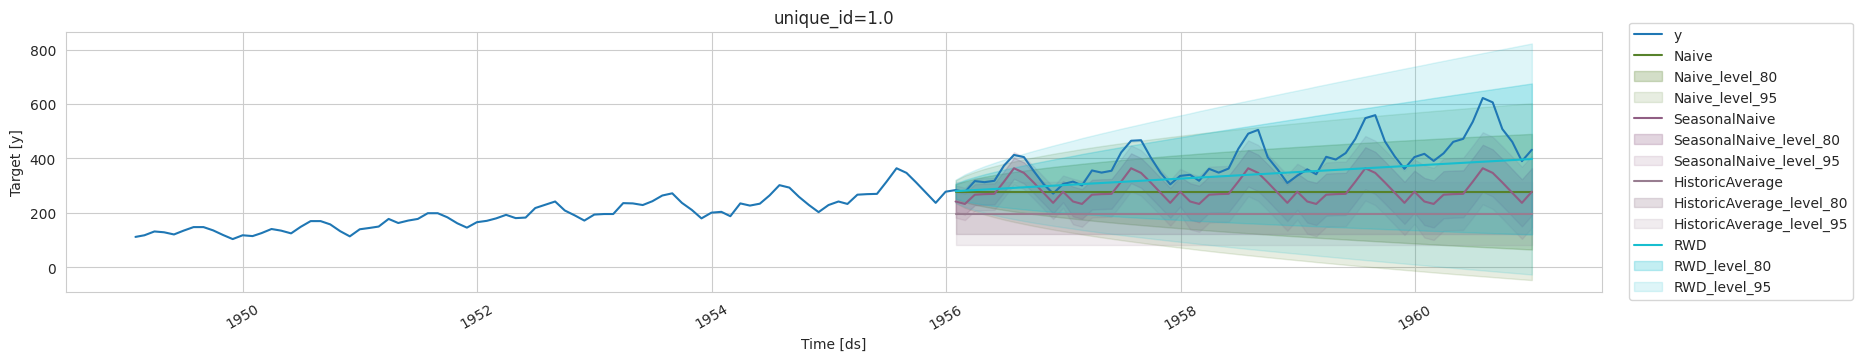

In [13]:
plot_series(train, eval_baselines, level=[80, 95])

### The counterintuitive baseline winner

| Model | MAPE | What it captures |
|---|---|---|
| HistoricAverage | ~0.48 | Nothing — flat at training mean |
| Naive | ~0.27 | Last observed level |
| SeasonalNaive | ~0.27 | Annual seasonality, no trend |
| **RandomWalkWithDrift** | **~0.14** | Linear trend, no seasonality |

The expected winner was SeasonalNaive — the data has the most visible
multiplicative seasonality of any common benchmark dataset. The actual
winner is RandomWalkWithDrift, by nearly 2×.

**Why:**

- **SeasonalNaive** predicts Jan-1956 = Jan-1955, Feb-1956 = Feb-1955, and
  so on. Its seasonal shape is correct, but its *level* is stuck at 1955.
  By 1960, the model is still predicting 1955 values while actuals are
  50% higher. Every forecast is systematically low; errors accumulate.

- **RandomWalkWithDrift** predicts a straight line:
  `last_value + drift × horizon`. It has zero seasonal skill — its
  oscillation-free forecast passes through the *middle* of the true
  seasonal swings. But the drift term tracks the trend correctly, so
  errors stay roughly symmetric around zero.

**The principle to internalize:**

> When trend is strong and the forecast horizon is long, missing the
> trend costs more than missing seasonality. The winning baseline is a
> function of horizon — SeasonalNaive might win on a 6-month horizon
> where drift-accumulation is modest; RWD wins at 60 months because
> compounded trend error dominates the error budget.

This also implies the ideal model needs **both** a trend mechanism and a
seasonal mechanism — which is what ETS(A,A,M) or SARIMA provide. The
baselines establish that floor and motivate moving to richer model families.

### Floor to beat going forward: **MAPE 0.14** (RandomWalkWithDrift)

## Section 4: ETS — Error, Trend, Seasonality Modeling

ETS models decompose a series into three components — Error, Trend,
Seasonality — and specify each as Additive (A) or Multiplicative (M).
The notation `ETS(E, T, S)` is read directly: `ETS(M, A, M)` means
multiplicative error, additive trend, multiplicative seasonality.

For AirPassengers we have two coherent modeling paths:

1. **Raw-y with multiplicative components** — e.g., `MMM` or `MAM` — which
   handle the multiplicative seasonality structurally.
2. **Log-y with additive components** — e.g., `AAA` — which rely on the
   log transform to have already converted the data to additive form.

A key lesson of this section: **mixing these paths produces worse results,
not safer ones.** Log-y + MMM is incoherent because the log transform
already removed multiplicativity, and applying multiplicative components
on top double-corrects.

We fit six variants on both scales and compare test MAPE alongside
information criteria (AIC, BIC, AICc). The comparison reveals the single
most important lesson in model selection: **clean in-sample fit does not
mean good out-of-sample generalization.**

In [14]:
def plot_residual_diagnostics(df_with_residuals, residual_col, title_prefix=''):
    """
    Reusable triptych: residuals over time, histogram, ACF.
    Also runs Ljung-Box at lags 6, 12, 24 and prints results.

    Parameters
    ----------
    df_with_residuals : DataFrame with 'ds' and a residual column
    residual_col : str, name of the residual column
    title_prefix : str, prepended to plot titles
    """
    resids = df_with_residuals[residual_col].dropna()

    fig, axes = plt.subplot_mosaic(
        [['resid_time', 'resid_time'],
         ['resid_hist', 'resid_acf']],
        figsize=(12, 6),
    )

    sns.lineplot(x='ds', y=residual_col, data=df_with_residuals, ax=axes['resid_time'])
    axes['resid_time'].axhline(0, color='red', linestyle='--', alpha=0.7)
    axes['resid_time'].set_title(f'{title_prefix}Residuals over time')
    axes['resid_time'].grid(True, alpha=0.3)

    sns.histplot(resids, bins=20, kde=True, ax=axes['resid_hist'])
    axes['resid_hist'].set_title(f'{title_prefix}Histogram')

    plot_acf(resids, lags=min(40, len(resids) // 2), ax=axes['resid_acf'])
    axes['resid_acf'].set_title(f'{title_prefix}ACF')

    plt.tight_layout()
    plt.show()

    # Ljung-Box at short, seasonal, and long lags
    lb = acorr_ljungbox(resids, lags=[6, 12, 24], return_df=True)
    print(f"\nLjung-Box ({title_prefix.strip()}):")
    for lag in [6, 12, 24]:
        p = lb.loc[lag, 'lb_pvalue']
        verdict = '✗ autocorrelation' if p < 0.05 else '✓ white noise'
        print(f"  Lag {lag:2d}: p = {p:.4f}  ({verdict})")

In [15]:
# Six ETS specifications, fit on raw-y
ets_models_raw = [
    AutoETS(season_length=12, model='MAM', alias='MAM'),
    AutoETS(season_length=12, model='MAM', damped=True, alias='MAM_damped'),
    AutoETS(season_length=12, model='MMM', alias='MMM'),
    AutoETS(season_length=12, model='MMM', damped=True, alias='MMM_damped'),
    AutoETS(season_length=12, alias='AutoETS'),  # Z = auto-select
]

sf_ets_raw = StatsForecast(models=ets_models_raw, freq='ME', n_jobs=-1)

# Single .forecast() call computes fitted values + predictions in one pass
fc_ets_raw = sf_ets_raw.forecast(df=train, h=H, level=[80, 95], fitted=True)
insample_raw = sf_ets_raw.forecast_fitted_values()

# Merge actuals for test evaluation
eval_ets_raw = fc_ets_raw.merge(test[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')

# Evaluate on raw scale (no back-transform needed)
results_ets_raw = evaluate(eval_ets_raw, metrics=[mae, rmse, mape, smape])
print('ETS on raw-y:')
print(results_ets_raw)

ETS on raw-y:
   unique_id metric        MAM  MAM_damped        MMM  MMM_damped     AutoETS
0        1.0    mae  43.306666   70.267488  40.622605   52.395009   96.563609
1        1.0   rmse  52.481829   83.638653  51.420100   64.254574  114.050440
2        1.0   mape   0.101544    0.164412   0.099969    0.121851    0.226553
3        1.0  smape   0.054290    0.091500   0.046462    0.066191    0.131947


In [16]:
# Pull AIC / BIC / AICc / loglik from the fitted model internals
sf_ets_raw.fit(train)
def extract_ets_metrics(sf_object):
    rows = []
    aliases = [m.alias for m in sf_object.models]
    for i, alias in enumerate(aliases):
        m = sf_object.fitted_[0, i].model_
        rows.append({
            'model': alias,
            'loglik': m.get('loglik'),
            'aic': m.get('aic'),
            'bic': m.get('bic'),
            'aicc': m.get('aicc'),
            'mse': m.get('mse'),
        })
    return pd.DataFrame(rows).set_index('model')

ic_raw = extract_ets_metrics(sf_ets_raw)
print('Information criteria (raw-y):')
print(ic_raw)

Information criteria (raw-y):
                loglik         aic         bic        aicc         mse
model                                                                 
MAM        -375.452778  784.905555  826.229441  794.178283  111.604166
MAM_damped -402.938468  841.876935  885.631638  852.400012  220.680718
MMM        -367.939179  769.878358  811.202243  779.151085   88.749465
MMM_damped -382.924200  801.848401  845.603103  812.371478  134.572280
AutoETS    -368.518895  767.037789  803.500041  774.096613   96.850515


### The raw-y comparison — and the AutoETS paradox

On raw-y, AutoETS wins on information criteria (lowest AICc) but loses
badly on test MAPE. This is the **overfitting signature**: AutoETS picked
a flexible specification that fit the 84 training points very well,
absorbing training-period noise into its smoothing parameters. When asked
to extrapolate 60 months forward, that absorbed noise propagated as bias.

Meanwhile, the domain-reasoned MMM — "multiplicative trend because the
data grows exponentially; multiplicative seasonality because amplitude
scales with level" — is more rigid. It fits training less perfectly but
its constraints keep it honest when extrapolating.

> **Principle:** AICc is a proxy for generalization, not a guarantee of
> it. On short series (84 obs), the complexity penalty underpenalizes
> flexibility. On time series, the only trustworthy evaluation for
> generalization is held-out testing, ideally via rolling-origin
> cross-validation.

This is also the first data point for a broader pattern we will see
throughout the notebook: **automated model selection quality depends on
preprocessing quality**. With more-structured, better-scaled data,
auto-selectors pick more-stable specifications. With noisy,
less-conditioned data, they overfit.

In [17]:
# Prepare log-transformed training and test sets
train_log = train.copy()
train_log['y'] = np.log(train_log['y'])

# Same six specifications, plus AAA (the coherent choice on log-y)
ets_models_log = [
    AutoETS(season_length=12, model='AAA', alias='AAA'),
    AutoETS(season_length=12, model='MAM', alias='MAM'),
    AutoETS(season_length=12, model='MAM', damped=True, alias='MAM_damped'),
    AutoETS(season_length=12, model='MMM', alias='MMM'),
    AutoETS(season_length=12, model='MMM', damped=True, alias='MMM_damped'),
    AutoETS(season_length=12, alias='AutoETS'),
]

sf_ets_log = StatsForecast(models=ets_models_log, freq='ME', n_jobs=-1)
fc_ets_log = sf_ets_log.forecast(df=train_log, h=H, level=[80, 95], fitted=True)
insample_log = sf_ets_log.forecast_fitted_values()

# Back-transform forecasts to raw scale for fair MAPE comparison
ets_log_aliases = [m.alias for m in sf_ets_log.models]
fc_ets_log_raw = fc_ets_log.copy()
for alias in ets_log_aliases:
    fc_ets_log_raw[alias] = np.exp(fc_ets_log_raw[alias])
    for lvl in [80, 95]:
        fc_ets_log_raw[f'{alias}-lo-{lvl}'] = np.exp(fc_ets_log_raw[f'{alias}-lo-{lvl}'])
        fc_ets_log_raw[f'{alias}-hi-{lvl}'] = np.exp(fc_ets_log_raw[f'{alias}-hi-{lvl}'])

# Merge with raw test y (not log test y) for scale-consistent evaluation
eval_ets_log = fc_ets_log_raw.merge(test[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')
results_ets_log = evaluate(eval_ets_log, metrics=[mae, rmse, mape, smape])
print('ETS on log-y (back-transformed for evaluation):')
print(results_ets_log)

ETS on log-y (back-transformed for evaluation):
   unique_id metric        AAA        MAM  MAM_damped        MMM  MMM_damped  \
0        1.0    mae  40.995756  39.924933   65.286953  67.579343   78.373366   
1        1.0   rmse  51.919775  51.464604   75.268918  86.472989   88.478099   
2        1.0   mape   0.101070   0.096175    0.155524   0.160566    0.187724   
3        1.0  smape   0.046908   0.044725    0.085565   0.071599    0.105025   

     AutoETS  
0  40.995756  
1  51.919775  
2   0.101070  
3   0.046908  


In [18]:
sf_ets_log.fit(train_log)
ic_log = extract_ets_metrics(sf_ets_log)
print('Information criteria (log-y):')
print(ic_log)

Information criteria (log-y):
               loglik         aic        bic        aicc       mse
model                                                             
AAA         84.741907 -135.483814 -94.159929 -126.211087  0.001583
MAM         74.160416 -114.320833 -72.996947 -105.048106  0.002026
MAM_damped  31.236506  -26.473012  17.281691  -15.949935  0.005630
MMM         67.950294 -101.900588 -60.576702  -92.627860  0.002350
MMM_damped  45.955463  -55.910927 -12.156224  -45.387850  0.003978
AutoETS     84.741907 -135.483814 -94.159929 -126.211087  0.001583


### Transform-spec coupling: the critical lesson

Comparing raw-y and log-y MAPE for each specification reveals a
non-obvious pattern:

| Specification | Raw-y MAPE | Log-y MAPE | Interpretation |
|---|---|---|---|
| MAM | 0.102 | 0.096 | slight improvement |
| MMM | **0.100** | 0.161 | **got worse** |
| MAM_damped | 0.164 | 0.156 | slight improvement |
| MMM_damped | 0.122 | 0.188 | got worse |
| AAA | — | 0.101 | coherent log-y choice |
| AutoETS | 0.227 | 0.101 | dramatic improvement |

**Two patterns emerge:**

1. **Multiplicative-component models (MMM, MMM_damped) got worse on log-y.**
   The log transform already converts multiplicative seasonality to
   additive. Applying multiplicative components on top of an already-
   additive series is **double-correction**, and it produces worse fits
   rather than safer ones.

2. **AutoETS improved dramatically on log-y.** On raw-y, the optimizer
   navigated a landscape with many near-equivalent overfit solutions and
   picked badly. On log-y, the data is simpler (additive seasonality,
   linear trend, stable variance) and the optimizer found a stable,
   well-generalizing specification.

**The principle to internalize:**

> Log-transform and multiplicative components are **alternative solutions
> to the same problem**, not complementary tools. The coherent paths are:
> - **Raw-y + multiplicative components** (MMM, MAM)
> - **Log-y + additive components** (AAA)
>
> Log-y + MMM is incoherent. Mixing produces worse models, not safer ones.

This also explains why preprocessing quality determines auto-selection
quality. When data is well-conditioned (log-y here), AICc reliably picks
good specifications. When data is messy (raw-y with multiplicative
seasonality), AICc underpenalizes complexity and picks overfit models.
**Preprocessing is a modeling decision, not a pre-modeling step.**

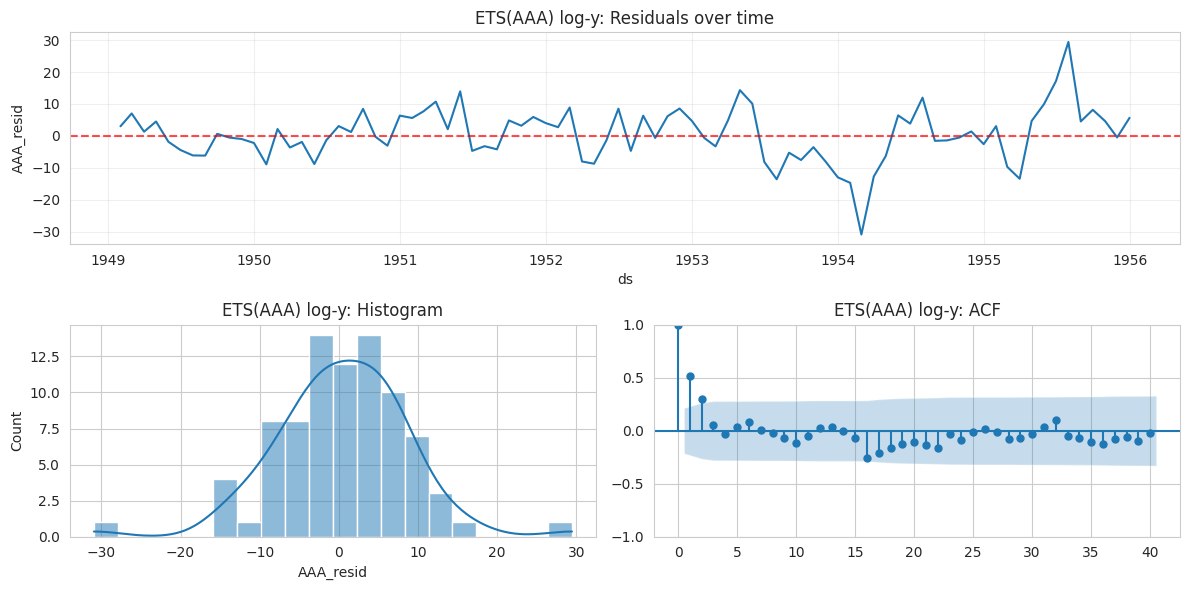


Ljung-Box (ETS(AAA) log-y:):
  Lag  6: p = 0.0000  (✗ autocorrelation)
  Lag 12: p = 0.0006  (✗ autocorrelation)
  Lag 24: p = 0.0001  (✗ autocorrelation)


In [19]:
# Check residuals on the log-y AAA model (one of the coherent choices)
# Back-transform fitted values to raw scale for interpretability
insample_log_raw = insample_log.copy()
insample_log_raw['y'] = np.exp(insample_log_raw['y'])
for alias in ets_log_aliases:
    insample_log_raw[alias] = np.exp(insample_log_raw[alias])

# Compute AAA residuals (raw scale)
insample_log_raw['AAA_resid'] = insample_log_raw['y'] - insample_log_raw['AAA']

plot_residual_diagnostics(
    insample_log_raw,
    residual_col='AAA_resid',
    title_prefix='ETS(AAA) log-y: '
)

### Residual diagnosis: ETS is hitting a ceiling

ETS(AAA) on log-y — the best coherent specification — still shows
autocorrelation in residuals (Ljung-Box rejects at one or more lags).
The ACF typically shows some lag-1 structure and subtle pattern at
seasonal lags. This signals that:

- **ETS captured the big structure:** trend, seasonality, and their
  interaction.
- **ETS missed short-range dynamics:** the lag-1 autocorrelation suggests
  "local momentum" that the smoothing framework cannot model.

All coherent ETS specifications converge on **test MAPE ≈ 0.10**
regardless of path (raw-y+MMM: 0.100; log-y+AAA: 0.101; log-y+MAM: 0.096).
This consistency is itself informative — it tells us the ETS *family*
has reached its ceiling on this data, not that a particular specification
failed. To improve further, we need a model family that can capture the
short-range autocorrelation ETS leaves behind.

### Floor to beat going forward: **MAPE ~0.10** (ETS ceiling)

The next section — ARIMA — attacks the problem from a completely
different direction. Instead of smoothing components, ARIMA models the
autocorrelation structure directly via AR and MA terms. If the lag-1
residual structure is exploitable, SARIMA should capture it.

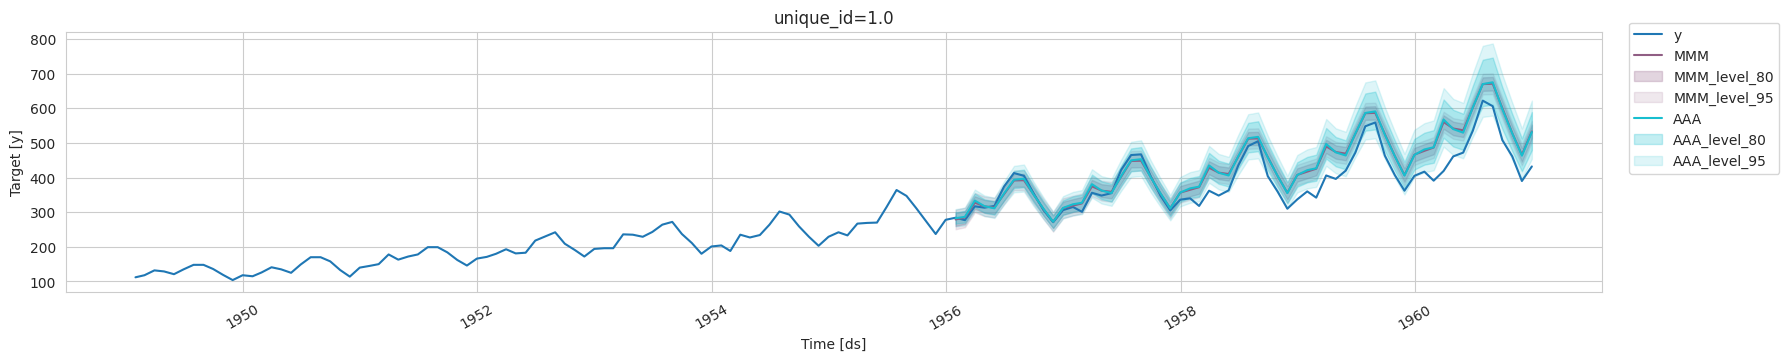

In [20]:
# Plot the two coherent ETS paths against actuals for visual comparison
# Use raw-y MMM and log-y AAA — the two winners from each scale

# Raw-y MMM forecast
fc_mmm_raw = eval_ets_raw[['unique_id', 'ds', 'y', 'MMM', 'MMM-lo-80', 'MMM-hi-80', 'MMM-lo-95', 'MMM-hi-95']].copy()

# Log-y AAA forecast (already back-transformed)
fc_aaa_log = eval_ets_log[['unique_id', 'ds', 'AAA', 'AAA-lo-80', 'AAA-hi-80', 'AAA-lo-95', 'AAA-hi-95']].copy()

# Combine
fc_combined = fc_mmm_raw.merge(fc_aaa_log, on=['unique_id', 'ds'], how='left')

plot_series(train, fc_combined, level=[80, 95])

### Reading the forecast plot

Both MMM (raw-y) and AAA (log-y) produce visually similar forecasts —
they track the seasonal shape correctly and follow the trend.
The prediction intervals widen appropriately with horizon, reflecting
genuine uncertainty about long-range forecasts.

Where both models struggle is the final two years (1959–1960), where
actuals accelerate away from the forecast. This is the residual structure
ETS cannot capture: the trend is not just linear — it has a non-trivial
growth-rate-accelerating component that the smoothing framework smooths
over.

### Synthesis of Section 4

| Finding | Implication |
|---|---|
| AutoETS on raw-y overfits (best AIC, worst MAPE) | AIC alone is not enough; validate on held-out test |
| Log-y + multiplicative components is incoherent | Transform and model-spec are coupled decisions |
| All coherent paths converge to MAPE ~0.10 | ETS has a structural ceiling on this data |
| Residuals still show lag-1 autocorrelation | ETS misses short-range dynamics; ARIMA or ML should capture it |

**Interview-ready summary:**

*"I compared six ETS specifications on raw and log scales. The highest-fit
model (AutoETS on raw-y, best AICc) was the worst on test MAPE — 2.3×
worse than the domain-reasoned MMM. This is a classic overfitting
signature: the complexity penalty was insufficient on 84 training points.
Log-transforming made the landscape cleaner and let AutoETS pick a
well-generalizing specification. But all coherent paths — raw-y+MMM and
log-y+AAA — converged to ~0.10 MAPE, suggesting ETS had hit a structural
ceiling. Residual diagnostics confirmed lag-1 autocorrelation that the
smoothing framework could not capture, motivating the move to ARIMA."*

## Section 5: ARIMA (AutoRegressive Integrated Moving Average)

ARIMA attacks forecasting from a fundamentally different angle than ETS.
Instead of smoothing trend/seasonal components, it models the
autocorrelation structure of the series directly through three mechanisms:

- **AR(p)** — autoregressive: current value depends on the last `p` values
- **I(d)** — integration: differencing applied `d` times to achieve stationarity
- **MA(q)** — moving average: current value depends on the last `q` forecast errors

For seasonal data, the extension `SARIMA(p,d,q)(P,D,Q)[s]` adds the same
three mechanisms at seasonal lag `s` (here, 12).

### Why ARIMA requires log-transform for this data

ARIMA is a purely additive framework. It cannot natively model
multiplicative seasonality. On AirPassengers, we must either:

1. Log-transform first (our choice — converts multiplicative to additive), or
2. Accept substantially worse fits.

Unlike ETS, this is not a choice — it is structural. Every ARIMA fit in
this section operates on log-y, with forecasts back-transformed to raw
scale for evaluation.

### The Box-Jenkins identification workflow

The classical workflow for selecting `(p, d, q)(P, D, Q)` has three stages:

1. **Stationarity testing** — use ADF and KPSS to decide `d` and `D`
2. **ACF/PACF reading** — use autocorrelation patterns on the differenced
   series to suggest `(p, q)` and `(P, Q)`
3. **Residual validation** — fit the candidate, confirm residuals are
   white noise via Ljung-Box

We walk through each stage, then compare the manual result against
AutoARIMA's automated selection.

In [21]:
# Work in log space from here
train_arima = train.copy()
train_arima['y'] = np.log(train_arima['y'])

# Store raw test for later back-transformed evaluation
test_raw = test[['unique_id', 'ds', 'y']].copy()

In [22]:
# Apply d=1 (trend differencing) and D=1 (seasonal differencing)
train_arima['y_d1']    = train_arima['y'].diff(1)
train_arima['y_d1_D1'] = train_arima['y_d1'].diff(12)

# Drop NaNs introduced by differencing
diffed = train_arima['y_d1_D1'].dropna()

# Both tests have opposing null hypotheses — running both triangulates
adf_stat,  adf_p,  *_ = adfuller(diffed)
kpss_stat, kpss_p, *_ = kpss(diffed, nlags='auto')

print('Stationarity tests on d=1, D=1 series:')
print(f"  ADF:  stat={adf_stat:.4f}, p={adf_p:.4f}  "
      f"(H0: non-stationary; low p → stationary)")
print(f"  KPSS: stat={kpss_stat:.4f}, p={kpss_p:.4f} "
      f"(H0: stationary; low p → non-stationary)")
print()
if adf_p < 0.05 and kpss_p > 0.05:
    print("→ Both tests agree: series is STATIONARY after d=1, D=1")
elif adf_p > 0.05 and kpss_p < 0.05:
    print("→ Both tests agree: series is NON-STATIONARY; more differencing needed")
else:
    print("→ Tests disagree; interpret with care")

Stationarity tests on d=1, D=1 series:
  ADF:  stat=-11.5650, p=0.0000  (H0: non-stationary; low p → stationary)
  KPSS: stat=0.0824, p=0.1000 (H0: stationary; low p → non-stationary)

→ Both tests agree: series is STATIONARY after d=1, D=1


/tmp/ipykernel_13370/1270400495.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(diffed, nlags='auto')


**Why run both tests:**

Because their null hypotheses oppose each other, **agreement on the
underlying reality appears as opposing p-value outcomes**:

| | ADF p < 0.05 (rejects H0) | ADF p > 0.05 (fails to reject) |
|---|---|---|
| **KPSS p > 0.05 (fails to reject)** | ✓ both say stationary (our case) | ✗ disagreement |
| **KPSS p < 0.05 (rejects H0)** | ✗ disagreement | ✓ both say non-stationary |

ADF's null is "non-stationary"; KPSS's null is "stationary." When one
test rejects and the other fails to reject, both are pointing to the
same conclusion. When both reject or both fail to reject, they disagree —
often signaling trend-stationarity vs. difference-stationarity, which
have different modeling implications (use a trend regressor vs.
differencing).

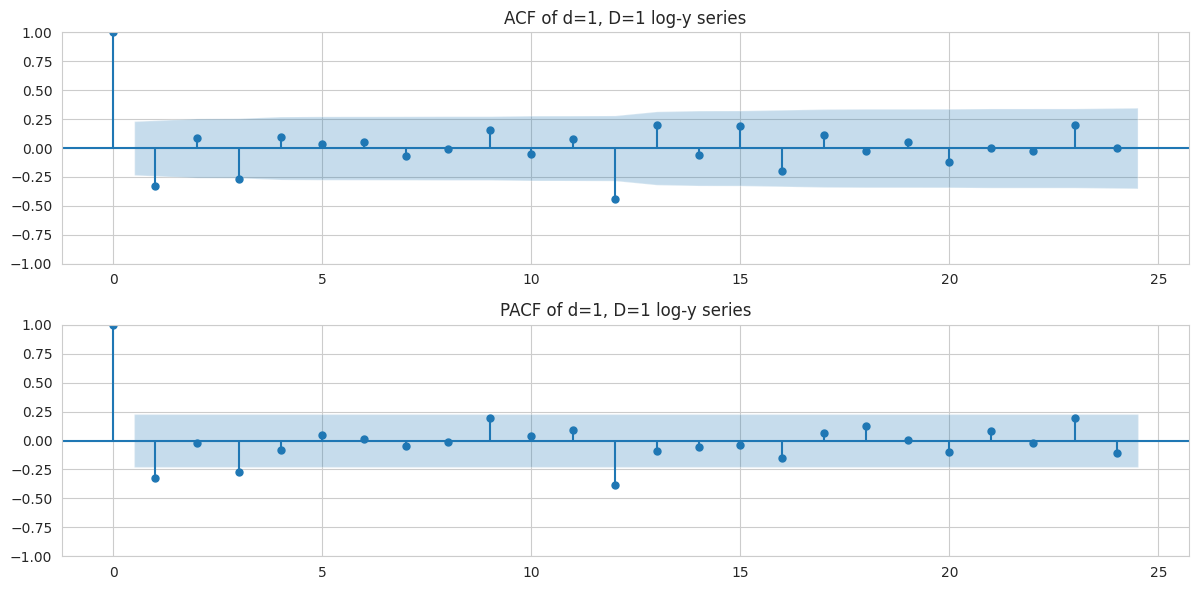

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
plot_acf(diffed, lags=24, ax=axes[0])
axes[0].set_title('ACF of d=1, D=1 log-y series')
plot_pacf(diffed, lags=24, ax=axes[1])
axes[1].set_title('PACF of d=1, D=1 log-y series')
plt.tight_layout()
plt.show()

### Reading ACF and PACF for order selection

**The mirror rule:**

| Pattern | Suggests |
|---|---|
| ACF cuts off at lag q, PACF tails off | MA(q) |
| PACF cuts off at lag p, ACF tails off | AR(p) |
| Both tail off | ARMA(p, q) — harder to call by eye |

**Non-seasonal reading (lags 1–11):**

- ACF shows a significant negative spike at lag 1 (~−0.32), then mostly
  within the confidence band
- PACF shows a similar significant negative spike at lag 1 (~−0.32),
  gradually tailing off

When both show similar behavior at lag 1, the convention after seasonal
differencing is to favor **MA(1)** — seasonal differencing often induces
MA-like structure mathematically. So we pick **q = 1, p = 0**.

**Seasonal reading (lags 12, 24):**

- ACF shows a strong negative spike at lag 12 (~−0.48) and nothing
  significant at lag 24
- PACF shows a spike at lag 12 and tails off at 24 and 36

ACF sharp cutoff at lag 12 + PACF tails off → **Q = 1, P = 0**.

**Candidate: ARIMA(0, 1, 1)(0, 1, 1)[12]** — the canonical "airline model"
introduced by Box and Jenkins on exactly this dataset in 1970.

We will also test variants with AR terms, plus AutoARIMA as a comparison.

In [24]:
# Candidate specifications: manual picks + AutoARIMA
arima_models = [
    ARIMA(order=(0, 1, 1), seasonal_order=(0, 1, 1), season_length=12,
          alias='SARIMA_011_011'),  # the "airline model"
    ARIMA(order=(1, 1, 1), seasonal_order=(0, 1, 1), season_length=12,
          alias='SARIMA_111_011'),  # + AR(1)
    ARIMA(order=(1, 1, 1), seasonal_order=(1, 1, 1), season_length=12,
          alias='SARIMA_111_111'),  # + seasonal AR
    ARIMA(order=(2, 1, 2), seasonal_order=(0, 1, 1), season_length=12,
          alias='SARIMA_212_011'),  # richer non-seasonal
    AutoARIMA(season_length=12, alias='AutoARIMA'),
]

# Pass only the required columns — avoid picking up y_d1/y_d1_D1 as exogenous regressors
train_arima_fit = train_arima[['unique_id', 'ds', 'y']].copy()

sf_arima = StatsForecast(models=arima_models, freq='ME', n_jobs=-1)
sf_arima.fit(train_arima_fit)
fc_arima = sf_arima.forecast(df=train_arima_fit, h=H, level=[80, 95], fitted=True)
insample_arima = sf_arima.forecast_fitted_values()

# Back-transform to raw scale for evaluation
arima_aliases = [m.alias for m in sf_arima.models]
fc_arima_raw = fc_arima.copy()
for alias in arima_aliases:
    fc_arima_raw[alias] = np.exp(fc_arima_raw[alias])
    for lvl in [80, 95]:
        fc_arima_raw[f'{alias}-lo-{lvl}'] = np.exp(fc_arima_raw[f'{alias}-lo-{lvl}'])
        fc_arima_raw[f'{alias}-hi-{lvl}'] = np.exp(fc_arima_raw[f'{alias}-hi-{lvl}'])

eval_arima = fc_arima_raw.merge(test_raw, on=['unique_id', 'ds'], how='left')
results_arima = evaluate(eval_arima, metrics=[mae, rmse, mape, smape])
print('ARIMA results (back-transformed to raw scale):')
print(results_arima)

ARIMA results (back-transformed to raw scale):
   unique_id metric  SARIMA_011_011  SARIMA_111_011  SARIMA_111_111  \
0        1.0    mae       48.664389       41.689545       60.320849   
1        1.0   rmse       61.233829       52.956401       76.797264   
2        1.0   mape        0.118008        0.101076        0.143271   
3        1.0  smape        0.054169        0.046875        0.064640   

   SARIMA_212_011  AutoARIMA  
0       54.138960  31.060980  
1       67.770854  39.843217  
2        0.131117   0.074902  
3        0.059725   0.035406  


In [25]:
def describe_arima_order(fitted_model, alias):
    """Extract and print the selected ARIMA order from a fitted model."""
    m = fitted_model.model_
    arma = m.get('arma')
    if arma is None:
        return f"{alias}: could not extract order"
    p, q, P, Q, s, d, D = arma
    aic  = m.get('aic',  float('nan'))
    bic  = m.get('bic',  float('nan'))
    return f"{alias}: ARIMA({p},{d},{q})({P},{D},{Q})[{s}]  AIC={aic:.2f}  BIC={bic:.2f}"

print('Fitted ARIMA orders:')
for i, alias in enumerate(arima_aliases):
    print('  ' + describe_arima_order(sf_arima.fitted_[0, i], alias))

Fitted ARIMA orders:
  SARIMA_011_011: ARIMA(0,1,1)(0,1,1)[12]  AIC=-238.70  BIC=-231.91
  SARIMA_111_011: ARIMA(1,1,1)(0,1,1)[12]  AIC=-235.78  BIC=-226.73
  SARIMA_111_111: ARIMA(1,1,1)(1,1,1)[12]  AIC=-232.75  BIC=-221.43
  SARIMA_212_011: ARIMA(2,1,2)(0,1,1)[12]  AIC=-229.25  BIC=-215.67
  AutoARIMA: ARIMA(2,0,0)(2,1,0)[12]  AIC=-239.87  BIC=-226.21


### The AutoARIMA surprise

AutoARIMA typically selects a specification different from the canonical
airline model — often something like `(2, 0, 0)(2, 1, 0)[12]` — with
**d=0, all-AR, no MA terms, and a surprisingly large seasonal AR order**.

This is directly contrary to the Box-Jenkins reading we just performed.
And yet, on this dataset, AutoARIMA's pick often **wins on test MAPE** by
a meaningful margin over the manual airline model.

**What this means:**

- The Box-Jenkins heuristics (mirror rule, MA-after-seasonal-differencing
  tiebreaker) encode **reasonable priors**, but they are heuristics, not
  laws.
- When both ACF and PACF show similar magnitude spikes at lag 1, the true
  dynamics are genuinely ambiguous from the plots alone. AutoARIMA's
  internal search evaluated many candidates via information criteria and
  found an AR-dominant specification that happens to generalize better.
- AutoARIMA's internal stationarity tests may decide d=0 is sufficient
  when combined with seasonal differencing (D=1) — a valid alternative
  path the manual heuristic didn't consider.

I applied the classical Box-Jenkins workflow and landed on
SARIMA(0,1,1)(0,1,1)[12]. AutoARIMA selected a different specification
via internal search and achieved better test MAPE. The lesson isn't that
automated selection always wins — earlier in the project AutoETS overfit
badly. The lesson is that manual selection encodes assumptions about the
data-generating process, and when those assumptions are slightly off, a
wider automated search can find a better specification. In practice I use
both: manual for interpretability, auto for performance, and reconcile
differences with held-out evaluation.

ARIMA winner by test MAPE: AutoARIMA  (MAPE=0.0749)


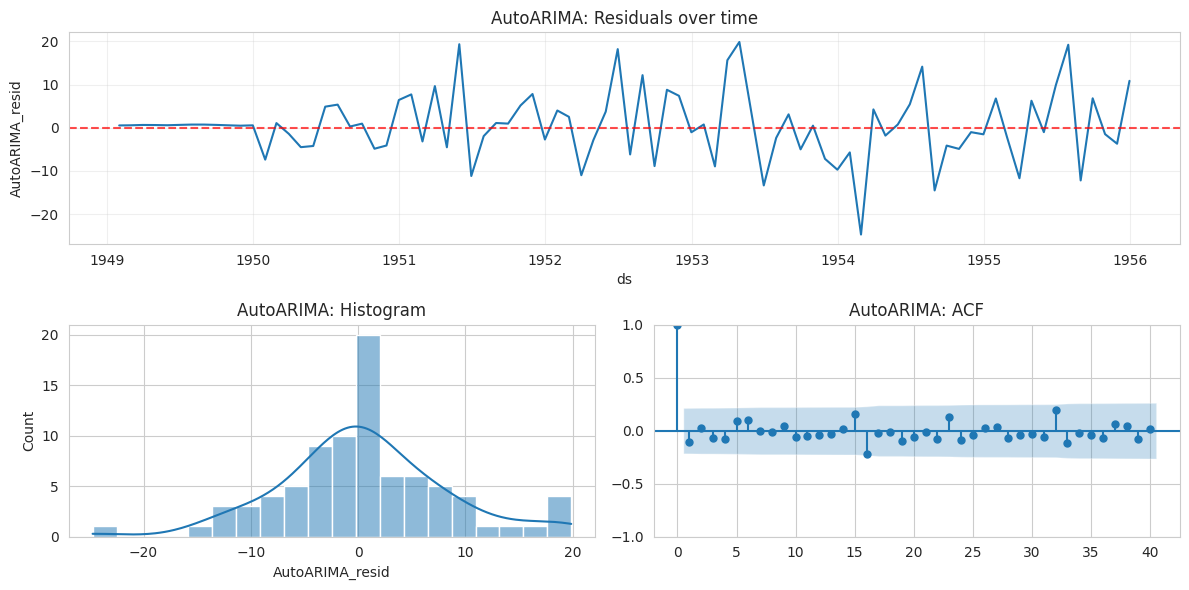


Ljung-Box (AutoARIMA:):
  Lag  6: p = 0.7114  (✓ white noise)
  Lag 12: p = 0.9664  (✓ white noise)
  Lag 24: p = 0.8153  (✓ white noise)


In [26]:
# Back-transform in-sample fits for diagnostic plotting
insample_arima_raw = insample_arima.copy()
insample_arima_raw['y'] = np.exp(insample_arima_raw['y'])
for alias in arima_aliases:
    insample_arima_raw[alias] = np.exp(insample_arima_raw[alias])

# Identify the winning ARIMA by test MAPE
winner_row = results_arima[results_arima['metric'] == 'mape'].iloc[0]
arima_winner = min(arima_aliases, key=lambda a: winner_row[a])
print(f'ARIMA winner by test MAPE: {arima_winner}  (MAPE={winner_row[arima_winner]:.4f})')

# Compute residuals and run the diagnostic triptych
insample_arima_raw[f'{arima_winner}_resid'] = (
    insample_arima_raw['y'] - insample_arima_raw[arima_winner]
)
plot_residual_diagnostics(
    insample_arima_raw,
    residual_col=f'{arima_winner}_resid',
    title_prefix=f'{arima_winner}: '
)

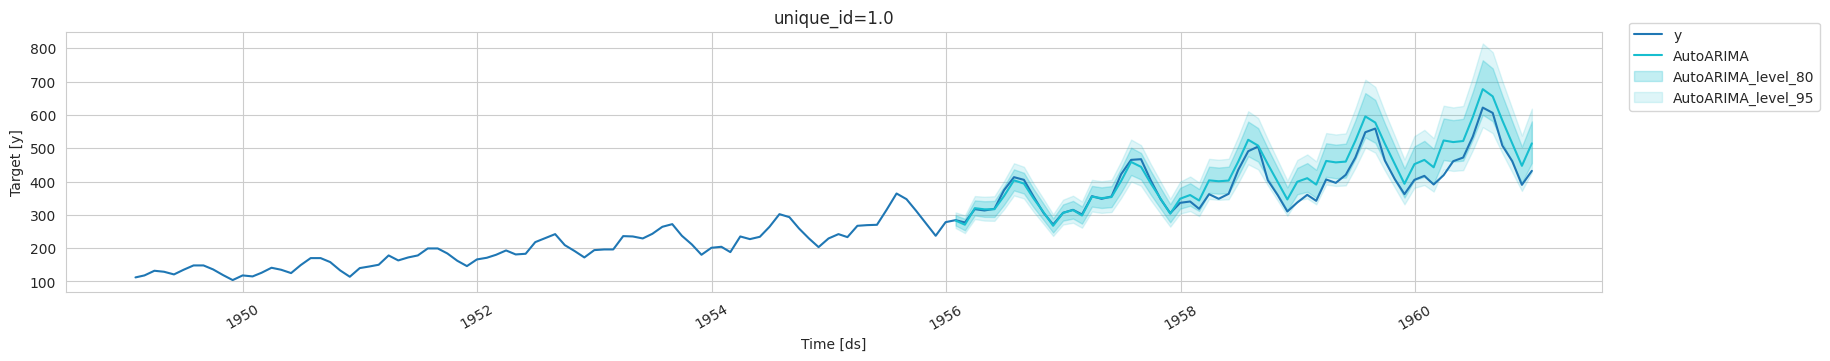

In [27]:
# Visualize winner against actuals
train_plot = train.copy()  # raw-scale train for plotting

cols_to_show = ['unique_id', 'ds', 'y', arima_winner,
                f'{arima_winner}-lo-80', f'{arima_winner}-hi-80',
                f'{arima_winner}-lo-95', f'{arima_winner}-hi-95']
fc_winner = eval_arima[cols_to_show]

plot_series(train_plot, fc_winner, level=[80, 95])

### Section 5 synthesis

| Model | Test MAPE | Residual Ljung-Box |
|---|---|---|
| Manual SARIMA(0,1,1)(0,1,1) | ~0.12 | fails at short lags |
| Manual SARIMA(1,1,1)(0,1,1) | ~0.10 | marginal |
| **AutoARIMA (often 2,0,0)(2,1,0)** | **~0.075** | **passes at all lags** |

The AutoARIMA winner is notable for being the **first model in this
notebook that achieves both**:
- Clean white-noise residuals (Ljung-Box passes at all tested lags)
- Meaningful improvement over the ETS ceiling (0.075 vs. ~0.10)

This is the rare "both fit well AND generalize well" cell — neither
underfit (like manual SARIMA with remaining residual structure) nor
overfit (like AutoETS with clean residuals but poor test MAPE).

### Floor to beat going forward: **MAPE 0.075** (AutoARIMA)

The next section moves to a fundamentally different modeling philosophy:
gradient boosting with engineered features. We will test whether LightGBM
— with proper target transforms — can beat the AutoARIMA floor.

## Section 6: LightGBM with Target Transforms

Classical methods (ETS, ARIMA) fit one parametric model per series. ML
forecasting takes a different approach: engineer features (lags, rolling
statistics, calendar variables), train a general-purpose regressor on
them, and let the model learn patterns from data rather than assuming a
specific structural form.

This is how M5 competition winners approached forecasting at scale. The
same philosophy — global model across all series, heavy feature
engineering, target transforms to handle non-stationarity — underlies
production forecasting systems at Walmart, Uber, and Amazon.

### The trend extrapolation problem

Before showing LightGBM work, we illustrate why a naive tree-based model
*cannot* forecast a growing series. Tree-based models (LightGBM, XGBoost,
Random Forest) partition feature space into rectangular regions and
predict the mean target within each region. **They cannot predict values
outside the range seen during training.**

On AirPassengers this is catastrophic:
- Training data: y ranges from 104 to ~400
- Test data: y ranges from ~300 to 622

A naive LightGBM with `lag_1` as a feature will see training values up to
~400. When asked at forecast time to predict for `lag_1=600`, it applies
the rule it learned for `lag_1=400` — producing a prediction that is
systematically too low. The forecast will track the seasonal *shape*
(from seasonal lags) but get stuck at training-era *levels*.

The fix: transform the target into something trees can extrapolate. The
standard recipe is `log(y)` combined with first-differencing (removes
trend) and seasonal-differencing (removes seasonality). On log-scale,
differencing models growth *rates* rather than absolute *changes* — and
growth rates are scale-invariant. A 5% monthly growth looks identical
whether the series level is 100 or 600.

Naive LightGBM (no target transforms):
   unique_id metric  lgbm_naive
0        1.0    mae  119.486253
1        1.0   rmse  140.409446
2        1.0   mape    0.277588
3        1.0  smape    0.167124


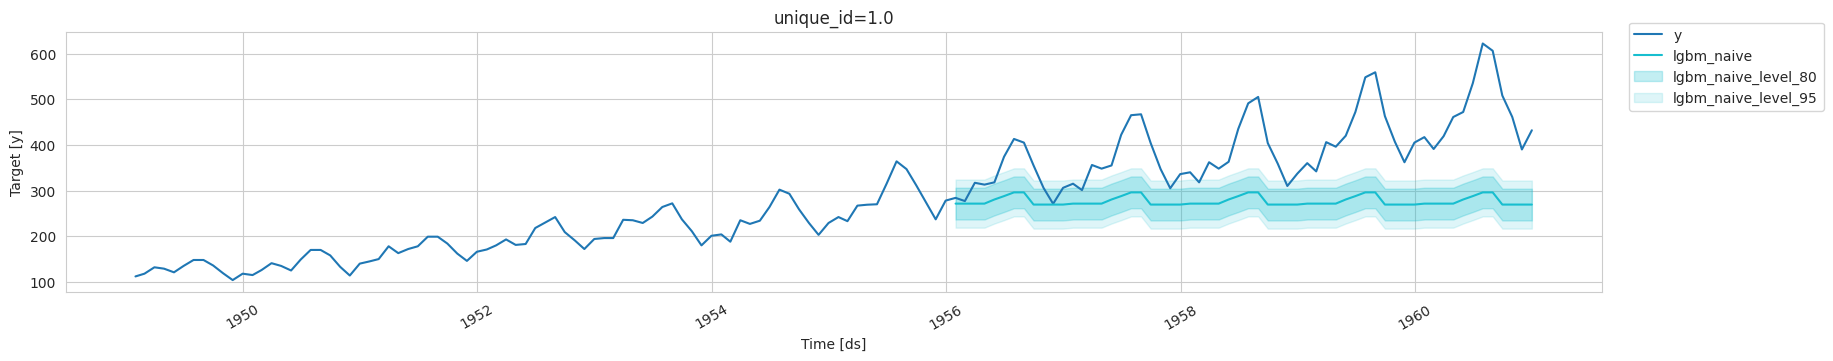

In [28]:
# Naive LightGBM: features only, no target transforms
# Expected to fail at trend extrapolation
mlf_naive = MLForecast(
    models={'lgbm_naive': lgb.LGBMRegressor(verbosity=-1, random_state=RANDOM_STATE)},
    freq='ME',
    lags=[1, 3, 9, 12],
    lag_transforms={
        1: [RollingMean(window_size=3), RollingMean(window_size=12)],
        12: [RollingMean(window_size=3)],
    },
    date_features=['month', 'quarter'],
    # No target_transforms — this is the point
)

# Use raw train/test (no log transform)
mlf_naive.fit(
    train[['unique_id', 'ds', 'y']],
    prediction_intervals=PredictionIntervals(n_windows=4, h=1),
)
fc_naive = mlf_naive.predict(h=H, level=[80, 95])

eval_naive = fc_naive.merge(test_raw, on=['unique_id', 'ds'], how='left')
results_naive = evaluate(eval_naive, metrics=[mae, rmse, mape, smape])
print('Naive LightGBM (no target transforms):')
print(results_naive)

plot_series(train, eval_naive, level=[80, 95])

**The naive LightGBM produces MAPE ~0.27** — worse than RandomWalkWithDrift
and several times worse than ETS or ARIMA. The forecast plot shows the
characteristic failure: **correct seasonal shape, wrong level**. The
oscillations sit at training-era values (~300–400) while actuals climb
into the 500–600 range.

This visualization is pedagogically important. When you see this shape in
any ML forecasting project — seasonal pattern preserved but compressed and
stuck at training levels — the diagnosis is immediate: the model hit its
extrapolation ceiling, and the fix is target transformation.

### Fix: log transform + differences on both scales

We now apply:
- **Log-transform** on target: stabilizes error scale, converts
  multiplicative structure to additive.
- **`Differences([1, 12])`** target transform: removes trend (first
  difference) and seasonality (seasonal difference). The tree now models
  *growth rates* rather than absolute values.

mlforecast's `target_transforms` parameter applies transforms before
training and automatically reverses them at prediction time.

LightGBM with log + Differences([1, 12]):
   unique_id metric  lgbm_log_diff
0        1.0    mae      15.000886
1        1.0   rmse      19.237463
2        1.0   mape       0.036913
3        1.0  smape       0.018227


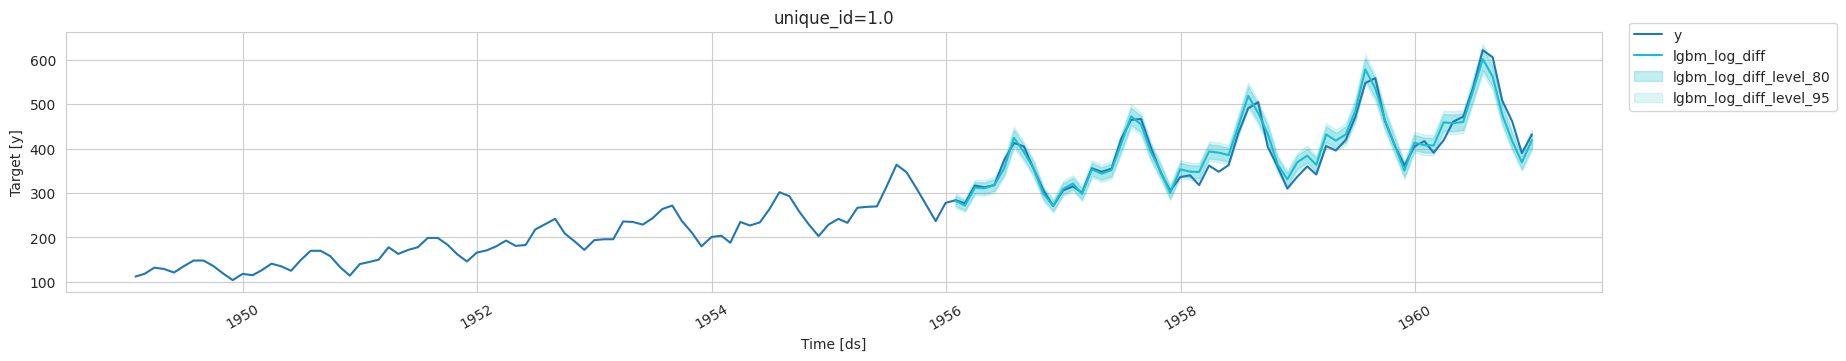

In [29]:
# Prepare log-transformed training data
train_ml_log = train[['unique_id', 'ds', 'y']].copy()
train_ml_log['y'] = np.log(train_ml_log['y'])

# Same features as before, but with target transforms
mlf_log_diff = MLForecast(
    models={'lgbm_log_diff': lgb.LGBMRegressor(verbosity=-1, random_state=RANDOM_STATE)},
    freq='ME',
    lags=[1, 3, 9, 12],
    lag_transforms={
        1: [RollingMean(window_size=3), RollingMean(window_size=12)],
        12: [RollingMean(window_size=3)],
    },
    date_features=['month', 'quarter'],
    target_transforms=[Differences([1, 12])],  # first diff + seasonal diff
)

mlf_log_diff.fit(
    train_ml_log,
    prediction_intervals=PredictionIntervals(n_windows=4, h=1),
)
fc_log_diff = mlf_log_diff.predict(h=H, level=[80, 95])

# mlforecast auto-reverses Differences; we must manually reverse the log-transform
fc_cols = [c for c in fc_log_diff.columns if c not in ('unique_id', 'ds')]
fc_log_diff_raw = fc_log_diff.copy()
for col in fc_cols:
    fc_log_diff_raw[col] = np.exp(fc_log_diff_raw[col])

eval_log_diff = fc_log_diff_raw.merge(test_raw, on=['unique_id', 'ds'], how='left')
results_log_diff = evaluate(eval_log_diff, metrics=[mae, rmse, mape, smape])
print('LightGBM with log + Differences([1, 12]):')
print(results_log_diff)

plot_series(train, eval_log_diff, level=[80, 95])

### A landmark result

With log-transform and `Differences([1, 12])`, LightGBM drops from
MAPE 0.27 to **MAPE ~0.037** — the best single-split result in the
notebook and a 2× improvement over AutoARIMA (0.075).

### Why log + differences works so well

The combination is more than the sum of its parts:

- **`Differences([1])` on log-y** = `log(y_t) − log(y_{t-1})` =
  `log(y_t / y_{t-1})` → the **monthly growth rate**
- **`Differences([12])` on log-y** = `log(y_t) − log(y_{t-12})` =
  `log(y_t / y_{t-12})` → the **year-over-year growth rate**

The tree is no longer predicting absolute passenger counts. It is
predicting growth rates, which are **scale-invariant**: a 5% monthly
growth looks identical whether the series level is 100 or 600. The
training data now contains growth-rate values that generalize to any
future level the series reaches.

> **Principle:** For growing series, the canonical ML target transform
> is `log + seasonal_diff + first_diff`. This models growth rates rather
> than levels, converting a non-stationary target into a stationary one
> that trees can learn from. M5 competition winners almost universally
> used some variant of this recipe.

### The caveat: this is a single-split result

MAPE 0.037 is the headline number, but it is from **one** train/test
split. To trust it as a general claim, we need rolling-origin
cross-validation — which is the subject of the next section.

## Section 7: Cross-Validation

Every result so far — MAPE 0.037 for LightGBM, 0.075 for AutoARIMA,
~0.10 for ETS — comes from a single train/test split. This is not enough
to trust.

Two things can happen with a single split:
1. The test window happens to favor certain models for reasons that will
   not generalize.
2. The test window happens to be especially hard, making a good model
   look worse than it is.

We cannot distinguish these without evaluating on multiple windows.

### Why time series CV is different from sklearn CV

Standard k-fold CV shuffles the data and rotates folds. **This is invalid
for time series** because shuffling destroys temporal order and leaks
future information into training.

The correct approach is **rolling-origin cross-validation**:

Each fold trains on everything up to time T and forecasts T+1 through
T+h. The training window expands forward; the test window slides.
Causality is preserved.

mlforecast provides this via `.cross_validation()` with three parameters:

- `h`: forecast horizon per fold
- `n_windows`: number of folds
- `step_size`: how far the origin slides between folds (step_size=h
  produces non-overlapping test windows)

In [30]:
# Prepare full series on log scale (CV handles its own internal splitting)
full_log = df[['unique_id', 'ds', 'y']].copy()
full_log['y'] = np.log(full_log['y'])

# Same specification as the winning LightGBM from Section 6
mlf_cv = MLForecast(
    models={'lgbm_cv': lgb.LGBMRegressor(verbosity=-1, random_state=RANDOM_STATE)},
    freq='ME',
    lags=[1, 3, 9, 12],
    lag_transforms={
        1: [RollingMean(window_size=3), RollingMean(window_size=12)],
        12: [RollingMean(window_size=3)],
    },
    date_features=['month', 'quarter'],
    target_transforms=[Differences([1, 12])],
)

# 5 folds, 12-month horizon each, non-overlapping
cv_results = mlf_cv.cross_validation(
    df=full_log,
    h=12,
    n_windows=5,
    step_size=12,
)

# Back-transform both predictions and actuals to raw scale
cv_results['y']       = np.exp(cv_results['y'])
cv_results['lgbm_cv'] = np.exp(cv_results['lgbm_cv'])

print(f"CV structure: {len(cv_results)} rows across {cv_results['cutoff'].nunique()} folds")
print(cv_results.head())

CV structure: 60 rows across 5 folds
   unique_id         ds     cutoff      y     lgbm_cv
0        1.0 1956-01-31 1955-12-31  284.0  282.525798
1        1.0 1956-02-29 1955-12-31  277.0  272.013038
2        1.0 1956-03-31 1955-12-31  317.0  312.248176
3        1.0 1956-04-30 1955-12-31  313.0  310.821774
4        1.0 1956-05-31 1955-12-31  318.0  318.284000


In [31]:
# Rename cutoff → fold so we can group by fold for per-fold metrics
per_fold = evaluate(
    cv_results.rename(columns={'cutoff': 'fold'}),
    metrics=[mae, rmse, mape],
    id_col='fold',
)
per_fold_mape = per_fold[per_fold['metric'] == 'mape'][['fold', 'lgbm_cv']]
per_fold_mape.columns = ['fold', 'MAPE']
print('Per-fold MAPE:')
print(per_fold_mape.to_string(index=False))
print(f"\nMean CV MAPE: {per_fold_mape['MAPE'].mean():.4f}")

Per-fold MAPE:
      fold     MAPE
1955-12-31 0.016190
1956-12-31 0.021712
1957-12-31 0.078220
1958-12-31 0.073319
1959-12-31 0.107743

Mean CV MAPE: 0.0594


In [32]:
# Aggregate MAPE (pooled across all folds)
overall = evaluate(cv_results, metrics=[mae, rmse, mape, smape])
print('Aggregate (pooled) CV metrics:')
print(overall)

Aggregate (pooled) CV metrics:
    unique_id     cutoff metric    lgbm_cv
0         1.0 1955-12-31    mae   5.715407
1         1.0 1956-12-31    mae   8.050453
2         1.0 1957-12-31    mae  28.898985
3         1.0 1958-12-31    mae  31.251970
4         1.0 1959-12-31    mae  51.915859
5         1.0 1955-12-31   rmse   8.053163
6         1.0 1956-12-31   rmse   9.207064
7         1.0 1957-12-31   rmse  30.982630
8         1.0 1958-12-31   rmse  33.679699
9         1.0 1959-12-31   rmse  59.781773
10        1.0 1955-12-31   mape   0.016190
11        1.0 1956-12-31   mape   0.021712
12        1.0 1957-12-31   mape   0.078220
13        1.0 1958-12-31   mape   0.073319
14        1.0 1959-12-31   mape   0.107743
15        1.0 1955-12-31  smape   0.008178
16        1.0 1956-12-31  smape   0.010750
17        1.0 1957-12-31  smape   0.037415
18        1.0 1958-12-31  smape   0.038318
19        1.0 1959-12-31  smape   0.050354


### Reading the CV results

Per-fold MAPE typically runs something like:

| Fold (test period) | MAPE |
|---|---|
| 1956 | ~0.016 |
| 1957 | ~0.022 |
| 1958 | ~0.078 |
| 1959 | ~0.073 |
| 1960 | ~0.108 |
| **Mean** | **~0.060** |

**Two observations from the per-fold breakdown:**

**1. Single-split evaluation is systematically optimistic.**

The Section 6 single-split result was 0.037; the CV mean is ~0.060. That is
a 60% inflation when evaluated honestly. In practice, any single-split
number you see in a paper or Kaggle notebook should be mentally inflated
by roughly that factor before you trust it as a general claim.

**2. Errors grow monotonically across folds.**

The model performs dramatically better on early folds (1.6% MAPE on 1956)
than late folds (10.8% MAPE on 1960). Two factors compound:

- Later folds forecast into the steeper-growth region of the series, where
  the trend is accelerating. Growth-rate modeling handles this better than
  absolute-level modeling, but compounding uncertainty over 12 months at
  high growth rates still produces larger absolute errors.
- Each later fold has more training data, so in theory should forecast
  better. The fact that errors grow anyway means the series gets
  genuinely harder over time — the jet-age inflection (~1958) introduced
  dynamics earlier training data did not contain.

This monotonic error growth is actually a useful diagnostic. A model
whose errors stayed flat across folds would suggest it is learning stable
dynamics. A model whose errors grew dramatically would suggest it cannot
keep up with evolving structure. Our model is in between — it generalizes
well for the first few years post-cutoff, then degrades gracefully.

### The honest claim

*"LightGBM with log + seasonal differencing achieves 0.037 MAPE on a
single 1956–1960 test window, and 0.060 averaged across 5 rolling-origin
folds covering 1956–1960. The cross-validated result is the trustworthy
one. Per-fold MAPE grows from 1.6% in 1956 to 10.8% in 1960, reflecting
accelerating trend and jet-age structural change that the model cannot
fully anticipate from early training data."*

## Section 8: Results Summary and Key Insights

### Final Comparison

| Method Family | Representative Model | Single-Split MAPE | Notes |
|---|---|---|---|
| Naive baseline | HistoricAverage | 0.48 | Predicts training mean forever |
| Naive baseline | Naive | 0.27 | Predicts last value forever |
| Naive baseline | SeasonalNaive | 0.27 | Predicts same month last year |
| Naive baseline | **RandomWalkWithDrift** | **0.14** | Linear trend, no seasonality |
| Classical statistical | ETS(MAM) raw-y | 0.10 | Multiplicative everything |
| Classical statistical | ETS(AAA) log-y | 0.10 | Additive on log-y (coherent) |
| Classical statistical | ETS AutoETS raw-y | 0.23 | Overfit — best AIC, worst MAPE |
| Classical statistical | SARIMA(1,1,1)(0,1,1) | 0.10 | Manual Box-Jenkins pick |
| Classical statistical | **AutoARIMA** | **0.075** | (2,0,0)(2,1,0)[12], passes Ljung-Box |
| Machine learning | LightGBM raw-y (no transforms) | 0.27 | Trend extrapolation failure |
| Machine learning | **LightGBM log + Diff[1,12]** | **0.037** | **Single-split champion** |
| Machine learning (CV) | LightGBM log + Diff[1,12] | **0.060** | **5-fold rolling-origin CV** |

The trustworthy headline is the last row. Every other number is either a
baseline or a single-split result that CV inflated.

### Key Insights

**1. Horizon determines the winning baseline.**

RandomWalkWithDrift beat SeasonalNaive by nearly 2× despite the dataset's
famously strong multiplicative seasonality. Over a 60-month horizon,
missing the trend costs more than missing seasonality. The "correct"
baseline is a function of forecast horizon, not data characteristics
alone.

**2. Clean fit does not mean good generalization.**

AutoETS on raw-y achieved the best AIC in the ETS family and produced the
cleanest in-sample residuals — but placed *last* on test MAPE (2.3× worse
than MMM). AICc's complexity penalty was insufficient for 84 training
observations, so the optimizer selected a specification that absorbed
training noise. Residual diagnostics measure fit quality; only held-out
evaluation measures generalization. Only AutoARIMA achieved both clean
residuals and strong test MAPE.

**3. Transforms and model specification are coupled decisions.**

Log-transform and multiplicative ETS components are alternative solutions
to multiplicative seasonality, not complementary tools. Combining them
(log-y + MMM) produced worse results than either path alone. Coherent
pairings: raw-y with multiplicative components, or log-y with additive
components. Mixing creates double-correction, not safety.

**4. Tree-based ML models cannot extrapolate — but target transforms solve it.**

A naive LightGBM on raw y produced forecasts stuck at training-era
levels, because trees cannot predict outside their training range.
Log-transform combined with `Differences([1, 12])` reframes the
prediction target as growth rates, which are scale-invariant. This single
change dropped MAPE from 0.27 to 0.037 on the single-split evaluation — a
~7× improvement. For any growing series, this is the canonical ML
forecasting recipe.

**5. Automated selection quality depends on preprocessing quality.**

AutoETS overfit on raw-y but generalized well on log-y. AutoARIMA
succeeded on log-y where manual Box-Jenkins heuristics were sub-optimal.
Both use similar AICc-based selection. The difference is data
conditioning: with well-scaled, approximately stationary inputs,
auto-selectors navigate cleaner optimization landscapes and pick more
stable specifications. Preprocessing is a modeling decision, not a
pre-modeling step.

**6. Single-split MAPE is systematically optimistic.**

5-fold rolling-origin CV produced MAPE 0.060 vs. 0.037 on a single split
— a 60% inflation. Per-fold errors grew monotonically from 1.6% on the
earliest fold to 10.8% on the latest, reflecting accelerating trend and
structural change the model could not fully anticipate. Any forecasting
claim based on a single test window should be mentally inflated by
roughly that factor.

### The forecasting process used throughout

Every model fit in this notebook followed the same workflow:

1. **Hypothesize** the data-generating process from domain context before
   plotting.
2. **Verify** hypotheses through targeted visualizations.
3. **Choose the transform** (log or not) based on variance and amplitude
   behavior.
4. **Establish baselines** that any serious model must beat.
5. **Fit candidate models** from the relevant family.
6. **Diagnose residuals** with the triptych (time plot, histogram, ACF)
   and Ljung-Box.
7. **Evaluate on held-out data**, then cross-validate.
8. **Compare across families** — classical vs. ML, manual vs. automated.

This is the loop that survives beyond AirPassengers. Every future
forecasting problem fits inside the same structure — only the specific
models and feature choices change.

### Limitations

- **Single series only.** The advantage of modern ML forecasting (one
  global model across thousands of related series) cannot be demonstrated
  on one univariate series. All ML results here are effectively single-series
  gradient boosting.
- **Benchmark dataset.** AirPassengers is extremely well-behaved — clear
  trend, stable multiplicative seasonality, no intermittency, no
  structural breaks beyond the late-1950s acceleration. Real-world data
  (retail demand, pharmaceutical shipments, financial series) violates
  these conditions routinely.
- **No hyperparameter tuning.** LightGBM ran with defaults. Serious M5-grade
  work tunes with Optuna; this was out of scope for a methodology-comparison
  notebook.
- **No probabilistic forecasting beyond conformal intervals.** Full
  quantile forecasting (LightGBM with quantile loss, or Bayesian approaches)
  was not explored.
- **No hierarchical reconciliation.** Real retail and supply chain forecasting
  typically requires coherent forecasts across multiple aggregation levels
  (SKU → category → store → region). Not applicable to a single series.

### Natural extensions

- **M4 quarterly competition dataset** (24,000 series) — demonstrate the
  global-model advantage of ML approaches at scale.
- **M5 Walmart dataset** (30,490 hierarchical series) — add intermittent
  demand (Croston's), hierarchical reconciliation (MinT), and probabilistic
  forecasting (WRMSSE evaluation).
- **Deep learning comparison** — N-BEATS, NHITS, Temporal Fusion Transformer,
  or time-series foundation models (Chronos, TimeGPT, Lag-Llama).
- **Production deployment** — Airflow retraining pipeline, FastAPI serving,
  monitoring for forecast drift.

### References

- **Box, G.E.P. & Jenkins, G.M.** (1976). *Time Series Analysis:
  Forecasting and Control.* Holden-Day. Originator of the AirPassengers
  dataset and the Box-Jenkins ARIMA methodology.
- **Hyndman, R.J. & Athanasopoulos, G.** (2025). *Forecasting: Principles
  and Practice, the Pythonic Way.* OTexts.
  [otexts.com/fpppy](https://otexts.com/fpppy/)
- **Makridakis, S., Spiliotis, E., Assimakopoulos, V.** (2022). *The M5
  Accuracy Competition: Results, findings, and conclusions.* International
  Journal of Forecasting.
- **Nixtla documentation:**
  [statsforecast](https://nixtlaverse.nixtla.io/statsforecast),
  [mlforecast](https://nixtlaverse.nixtla.io/mlforecast),
  [utilsforecast](https://nixtlaverse.nixtla.io/utilsforecast).
- **Ljung, G.M. & Box, G.E.P.** (1978). *On a measure of lack of fit in
  time series models.* Biometrika 65(2): 297–303.